In [63]:
import os
import pandas as pd
from hashlib import md5
from PIL import Image

## Baseline clustering

In [64]:
baseline_data_path = "/srv/defectDetectionDataset/multiclassClassification/baseline"

artifacts_path = "/home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/baseline"

In [65]:
baseline_images = []

extensions = [".png", ".jpg", ".jpeg"]

for dirpath, dirnames, filenames in os.walk(baseline_data_path):
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            img = Image.open(file_path)
            image_id = md5(img.tobytes()).hexdigest()
            baseline_images.append({"image_id": image_id, "file_path": file_path, "label": label})


df = pd.DataFrame(baseline_images)

In [66]:
print(f"Number of images in baseline: {len(baseline_images)}")

Number of images in baseline: 5586


In [68]:
df.to_csv(os.path.join(artifacts_path, "baseline_images.csv"), index=False)

## Find exact duplicates by file hashes

### Duplicates in old data

In [70]:
duplicates_ids = df[df.duplicated(subset=['image_id'], keep="first")]['image_id'].unique()

print(f"Number of duplicate images in baseline dataset: {len(duplicates_ids)}")

# Mark duplicates in the dataframe
df['is_duplicate'] = df['image_id'].isin(duplicates_ids)

Number of duplicate images in baseline dataset: 44


## Find near duplicates with pretrained model

In [71]:
import torch
from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
import numpy as np
import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load MobileNetV3-Large with pretrained weights
weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
model = models.mobilenet_v3_large(weights=weights)
model.to(device)

# Define transforms
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transform = v2.Compose([
    v2.Resize(480, antialias=True),
    v2.CenterCrop(480),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

model.eval()

embeddings = []

@torch.no_grad()
def get_mobilenet_embedding(model, img_tensor):
    """Extract features from MobileNetV3 before classifier"""
    feats = model.features(img_tensor)
    feats = model.avgpool(feats)
    feats = torch.flatten(feats, 1)
    return torch.nn.functional.normalize(feats, dim=1)

for idx, row in df.iterrows():
    img = Image.open(row["file_path"]).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    embedding = get_mobilenet_embedding(model, img_tensor)
    embedding = embedding.cpu().numpy().flatten()
    
    embeddings.append({
        "image_id": row["image_id"],
        "embedding": embedding
    })
    
    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1}/{len(df)} images")

# Save embeddings
embeddings_array = np.array([e["embedding"] for e in embeddings])
image_ids = [e["image_id"] for e in embeddings]

np.save(os.path.join(artifacts_path, "image_embeddings.npy"), embeddings_array)
pd.DataFrame({"image_id": image_ids}).to_csv(os.path.join(artifacts_path, "image_embeddings_ids.csv"), index=False)

print(f"Generated embeddings for {len(embeddings)} images")
print(f"Embedding shape: {embeddings_array.shape}")

Processed 100/5586 images
Processed 200/5586 images
Processed 300/5586 images
Processed 400/5586 images
Processed 500/5586 images
Processed 600/5586 images
Processed 700/5586 images
Processed 800/5586 images
Processed 900/5586 images
Processed 1000/5586 images
Processed 1100/5586 images
Processed 1200/5586 images
Processed 1300/5586 images
Processed 1400/5586 images
Processed 1500/5586 images
Processed 1600/5586 images
Processed 1700/5586 images
Processed 1800/5586 images
Processed 1900/5586 images
Processed 2000/5586 images
Processed 2100/5586 images
Processed 2200/5586 images
Processed 2300/5586 images
Processed 2400/5586 images
Processed 2500/5586 images
Processed 2600/5586 images
Processed 2700/5586 images
Processed 2800/5586 images
Processed 2900/5586 images
Processed 3000/5586 images
Processed 3100/5586 images
Processed 3200/5586 images
Processed 3300/5586 images
Processed 3400/5586 images
Processed 3500/5586 images
Processed 3600/5586 images
Processed 3700/5586 images
Processed 

In [72]:
embeddings_dict = {image_id: embeddings_array[idx] for idx, image_id in enumerate(image_ids)}

import faiss

dimension = embeddings_array.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings_array)
print(f"FAISS index built with {index.ntotal} vectors of dimension {dimension}")

# search for 20 nearest neighbors
k = 20
D, I = index.search(embeddings_array, k)
D, I = torch.from_numpy(D), torch.from_numpy(I)#
# D: distances, I: indices of nearest neighbors

FAISS index built with 5586 vectors of dimension 960


In [73]:
from shutil import copy2

high_threshold = 0.99
medium_threshold = 0.92
low_threshold = 0.85


# Calculate cosine similarity from L2 distances
# Convert L2 distance to cosine similarity: similarity = 1 - (L2_distance^2 / 2)
similarities = 1 - (D ** 2 / 2)

# Create similarity pairs with image IDs
similarity_pairs = []
for i in range(len(similarities)):
    for j in range(1, k):  # Skip first neighbor (itself)
        img_id_1 = image_ids[i]
        img_id_2 = image_ids[I[i][j].item()]
        sim_score = similarities[i][j].item()
        similarity_pairs.append({
            "image_id_1": img_id_1,
            "image_id_2": img_id_2,
            "similarity": sim_score
        })

similarity_df = pd.DataFrame(similarity_pairs)

# Save all similarity pairs to CSV
similarity_df.to_csv(os.path.join(artifacts_path, "similarity_pairs.csv"), index=False)
print(f"Saved {len(similarity_df)} similarity pairs to {os.path.join(artifacts_path, 'similarity_pairs.csv')}")

# Filter by thresholds
high_sim = similarity_df[similarity_df["similarity"] >= high_threshold]
medium_sim = similarity_df[(similarity_df["similarity"] >= medium_threshold) & 
                           (similarity_df["similarity"] < high_threshold)]
low_sim = similarity_df[(similarity_df["similarity"] >= low_threshold) & 
                        (similarity_df["similarity"] < medium_threshold)]

print(f"High similarity pairs (>= {high_threshold}): {len(high_sim)}")
print(f"Medium similarity pairs ({medium_threshold} - {high_threshold}): {len(medium_sim)}")
print(f"Low similarity pairs ({low_threshold} - {medium_threshold}): {len(low_sim)}")

# Sample 150 pairs from each category
n_samples = min(150, len(high_sim), len(medium_sim), len(low_sim))
high_sample = high_sim.sample(n=min(n_samples, len(high_sim)), random_state=42)
medium_sample = medium_sim.sample(n=min(n_samples, len(medium_sim)), random_state=42)
low_sample = low_sim.sample(n=min(n_samples, len(low_sim)), random_state=42)

# Create output directory
output_dir = os.path.join(artifacts_path, "cluster_samples")
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/high", exist_ok=True)
os.makedirs(f"{output_dir}/medium", exist_ok=True)
os.makedirs(f"{output_dir}/low", exist_ok=True)

# Copy sampled image pairs and create pair manifest

def copy_pair(row, idx, category):
    img1_path = df[df["image_id"] == row["image_id_1"]]["file_path"].values[0]
    img2_path = df[df["image_id"] == row["image_id_2"]]["file_path"].values[0]
    
    ext1 = os.path.splitext(img1_path)[1]
    ext2 = os.path.splitext(img2_path)[1]
    
    copy2(img1_path, f"{output_dir}/{category}/pair_{idx:03d}_img1{ext1}")
    copy2(img2_path, f"{output_dir}/{category}/pair_{idx:03d}_img2{ext2}")

# Create manifest for sampled pairs
sampled_pairs = []
pair_counter = 0

for idx, row in high_sample.iterrows():
    copy_pair(row, pair_counter, "high")
    sampled_pairs.append({
        "pair_id": f"high_pair_{pair_counter:03d}",
        "image_id_a": row["image_id_1"],
        "image_id_b": row["image_id_2"],
        "similarity": row["similarity"],
        "category": "high"
    })
    pair_counter += 1

pair_counter = 0
for idx, row in medium_sample.iterrows():
    copy_pair(row, pair_counter, "medium")
    sampled_pairs.append({
        "pair_id": f"medium_pair_{pair_counter:03d}",
        "image_id_a": row["image_id_1"],
        "image_id_b": row["image_id_2"],
        "similarity": row["similarity"],
        "category": "medium"
    })
    pair_counter += 1

pair_counter = 0
for idx, row in low_sample.iterrows():
    copy_pair(row, pair_counter, "low")
    sampled_pairs.append({
        "pair_id": f"low_pair_{pair_counter:03d}",
        "image_id_a": row["image_id_1"],
        "image_id_b": row["image_id_2"],
        "similarity": row["similarity"],
        "category": "low"
    })
    pair_counter += 1

# Save sampled pairs manifest
sampled_pairs_df = pd.DataFrame(sampled_pairs)
sampled_pairs_df.to_csv(f"{output_dir}/sampled_pairs.csv", index=False)

print(f"Copied {len(high_sample)} high similarity pairs")
print(f"Copied {len(medium_sample)} medium similarity pairs")
print(f"Copied {len(low_sample)} low similarity pairs")
print(f"Saved sampled pairs manifest to {output_dir}/sampled_pairs.csv")

Saved 106134 similarity pairs to /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/baseline/similarity_pairs.csv
High similarity pairs (>= 0.99): 11515
Medium similarity pairs (0.92 - 0.99): 78287
Low similarity pairs (0.85 - 0.92): 12827
Copied 150 high similarity pairs
Copied 150 medium similarity pairs
Copied 150 low similarity pairs
Saved sampled pairs manifest to /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/baseline/cluster_samples/sampled_pairs.csv


## Threshold Analysis: Precision and Recall

In [54]:
# Load labeled data
labels_df = pd.read_csv("artifacts/cluster_samples/labels.csv")

print(f"Total labeled pairs: {len(labels_df)}")
print(f"\nLabel distribution:")
print(labels_df["label"].value_counts())

# Define positive (duplicates) and negative (not duplicates) classes
positive_labels = {"EXACT", "SAME_INSTANCE"}
negative_labels = {"DIFF_INSTANCE"}

# Add binary classification column
labels_df["is_duplicate"] = labels_df["label"].isin(positive_labels)

print(f"\nPositive samples (EXACT/SAME_INSTANCE): {labels_df['is_duplicate'].sum()}")
print(f"Negative samples (DIFF_INSTANCE): {(~labels_df['is_duplicate']).sum()}")

Total labeled pairs: 450

Label distribution:
label
DIFF_INSTANCE    188
SAME_INSTANCE    164
AMBIGUOUS         95
EXACT              3
Name: count, dtype: int64

Positive samples (EXACT/SAME_INSTANCE): 167
Negative samples (DIFF_INSTANCE): 283


In [ ]:
# Sweep through multiple thresholds and calculate precision/recall
import numpy as np

# Define threshold range
thresholds = np.arange(0.85, 1.0, 0.005)

results = []

for threshold in thresholds:
    # Predict: if similarity >= threshold, predict as duplicate (positive)
    labels_df["predicted_duplicate"] = labels_df["similarity"] >= threshold
    
    # Calculate confusion matrix components
    tp = ((labels_df["predicted_duplicate"] == True) & (labels_df["is_duplicate"] == True)).sum()
    fp = ((labels_df["predicted_duplicate"] == True) & (labels_df["is_duplicate"] == False)).sum()
    tn = ((labels_df["predicted_duplicate"] == False) & (labels_df["is_duplicate"] == False)).sum()
    fn = ((labels_df["predicted_duplicate"] == False) & (labels_df["is_duplicate"] == True)).sum()
    
    # Calculate metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / len(labels_df)
    
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "accuracy": accuracy,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn
    })

results_df = pd.DataFrame(results)
results_df.to_csv("artifacts/threshold_analysis.csv", index=False)

print(f"Analyzed {len(thresholds)} thresholds")
print(f"\nBest F1 score: {results_df['f1_score'].max():.4f} at threshold {results_df.loc[results_df['f1_score'].idxmax(), 'threshold']:.4f}")
print(f"Best precision: {results_df['precision'].max():.4f} at threshold {results_df.loc[results_df['precision'].idxmax(), 'threshold']:.4f}")
print(f"Best recall: {results_df['recall'].max():.4f} at threshold {results_df.loc[results_df['recall'].idxmax(), 'threshold']:.4f}")

# Display top 10 results by F1 score
print("\nTop 10 thresholds by F1 score:")
print(results_df.nlargest(10, "f1_score")[["threshold", "precision", "recall", "f1_score", "accuracy"]])

Analyzed 26 thresholds

Best F1 score: 0.7135 at threshold 0.9700
Best precision: 0.8966 at threshold 0.9950
Best recall: 1.0000 at threshold 0.8700

Top 10 thresholds by F1 score:
    threshold  precision    recall  f1_score  accuracy
20      0.970   0.650246  0.790419  0.713514  0.764444
21      0.975   0.673797  0.754491  0.711864  0.773333
19      0.965   0.624434  0.826347  0.711340  0.751111
18      0.960   0.604255  0.850299  0.706468  0.737778
17      0.955   0.584677  0.868263  0.698795  0.722222
22      0.980   0.683908  0.712575  0.697947  0.771111
23      0.985   0.712500  0.682635  0.697248  0.780000
24      0.990   0.726667  0.652695  0.687697  0.780000
16      0.950   0.560606  0.886228  0.686775  0.700000
15      0.945   0.543478  0.898204  0.677201  0.682222


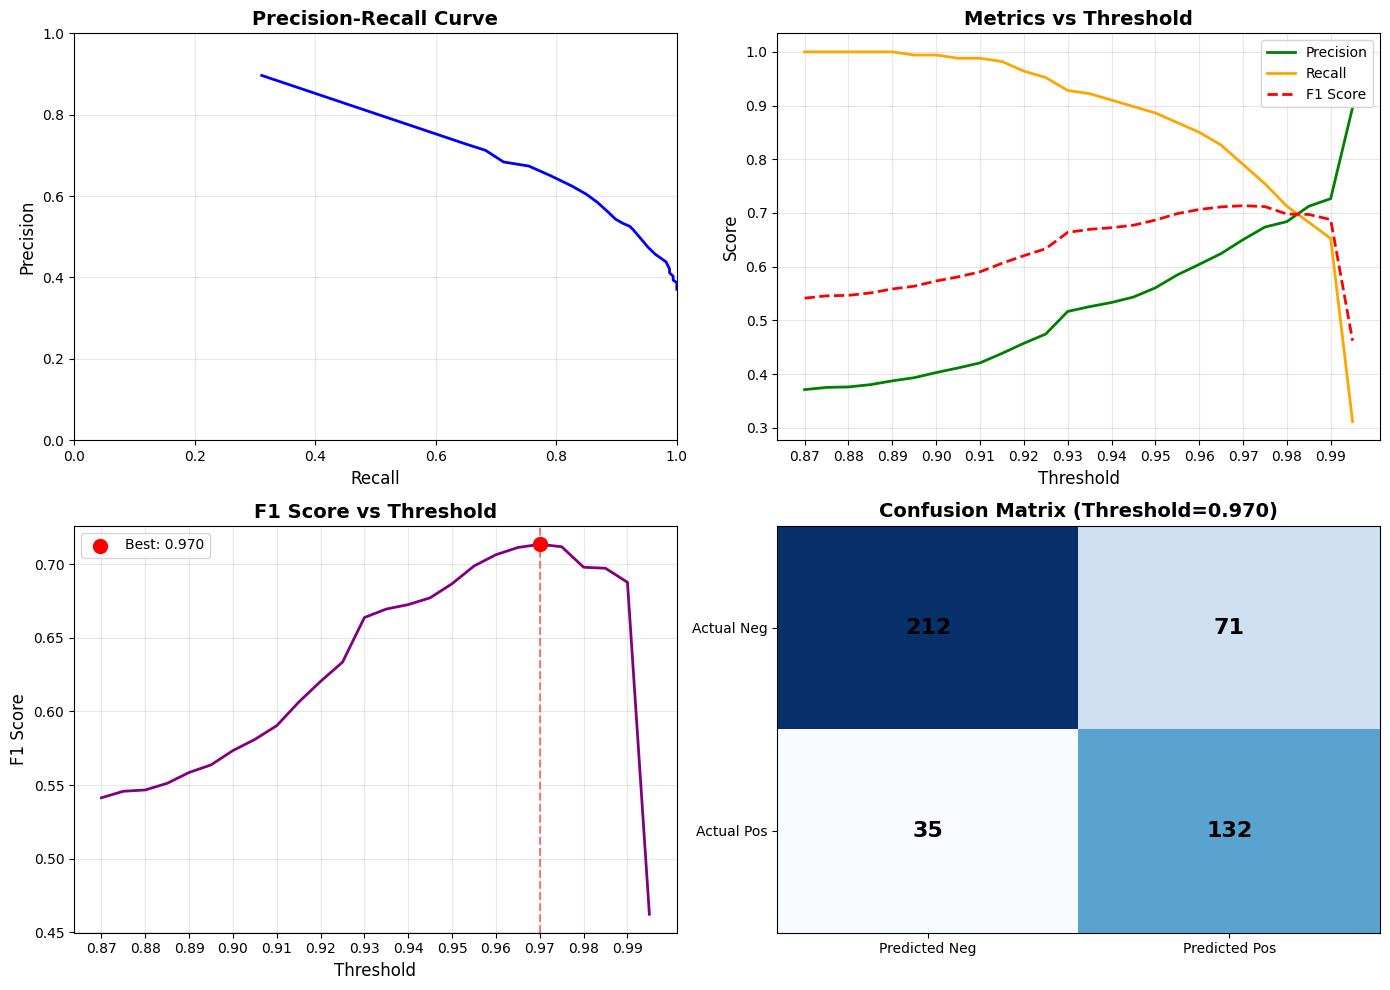


Plots saved to artifacts/threshold_analysis.png


In [65]:
# Plot Precision-Recall curve and other metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Precision-Recall curve
axes[0, 0].plot(
    results_df["recall"], results_df["precision"], linewidth=2, color="blue"
)
axes[0, 0].set_xlabel("Recall", fontsize=12)
axes[0, 0].set_ylabel("Precision", fontsize=12)
axes[0, 0].set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim([0, 1])
axes[0, 0].set_ylim([0, 1])

# 2. Precision and Recall vs Threshold
axes[0, 1].plot(
    results_df["threshold"],
    results_df["precision"],
    label="Precision",
    linewidth=2,
    color="green",
)
axes[0, 1].plot(
    results_df["threshold"],
    results_df["recall"],
    label="Recall",
    linewidth=2,
    color="orange",
)
axes[0, 1].plot(
    results_df["threshold"],
    results_df["f1_score"],
    label="F1 Score",
    linewidth=2,
    color="red",
    linestyle="--",
)
axes[0, 1].set_xlabel("Threshold", fontsize=12)
axes[0, 1].set_ylabel("Score", fontsize=12)
axes[0, 1].set_xticks(np.arange(0.87, 1.00, 0.01))
axes[0, 1].set_title("Metrics vs Threshold", fontsize=14, fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. F1 Score vs Threshold (zoomed)
axes[1, 0].plot(
    results_df["threshold"], results_df["f1_score"], linewidth=2, color="purple"
)
best_f1_idx = results_df["f1_score"].idxmax()
best_threshold = results_df.loc[best_f1_idx, "threshold"]
best_f1 = results_df.loc[best_f1_idx, "f1_score"]
axes[1, 0].scatter(
    [best_threshold],
    [best_f1],
    color="red",
    s=100,
    zorder=5,
    label=f"Best: {best_threshold:.3f}",
)
axes[1, 0].axvline(x=best_threshold, color="red", linestyle="--", alpha=0.5)
axes[1, 0].set_xlabel("Threshold", fontsize=12)
axes[1, 0].set_ylabel("F1 Score", fontsize=12)
axes[1, 0].set_xticks(np.arange(0.87, 1.00, 0.01))
axes[1, 0].set_title("F1 Score vs Threshold", fontsize=14, fontweight="bold")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Confusion Matrix counts at best threshold
best_result = results_df.iloc[best_f1_idx]
confusion_data = [
    [best_result["tn"], best_result["fp"]],
    [best_result["fn"], best_result["tp"]],
]
im = axes[1, 1].imshow(confusion_data, cmap="Blues", aspect="auto")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(["Predicted Neg", "Predicted Pos"])
axes[1, 1].set_yticklabels(["Actual Neg", "Actual Pos"])
axes[1, 1].set_title(
    f"Confusion Matrix (Threshold={best_threshold:.3f})", fontsize=14, fontweight="bold"
)

# Add text annotations
for i in range(2):
    for j in range(2):
        text = axes[1, 1].text(
            j,
            i,
            int(confusion_data[i][j]),
            ha="center",
            va="center",
            color="black",
            fontsize=16,
            fontweight="bold",
        )

plt.tight_layout()
plt.savefig("artifacts/threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPlots saved to artifacts/threshold_analysis.png")

ROC AUC Score: 0.8446


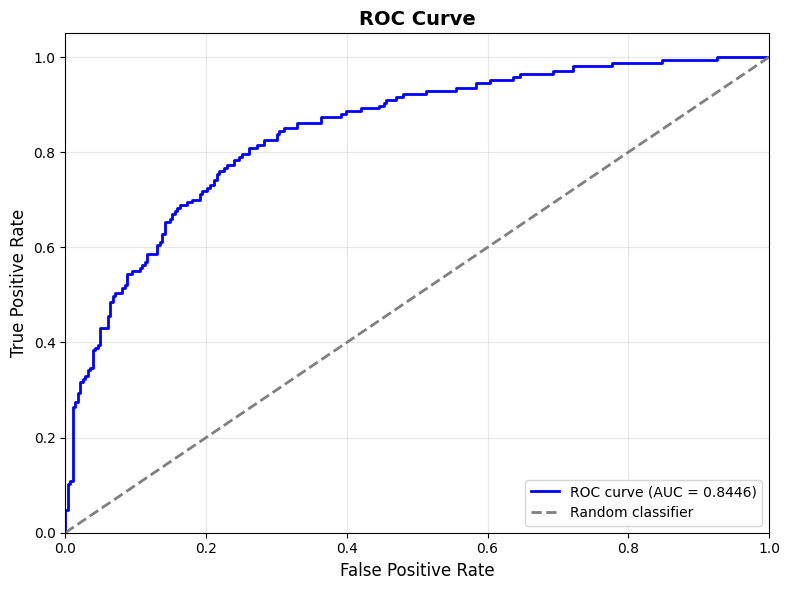


ROC curve saved to artifacts/roc_curve.png

Classification Performance Summary:
ROC AUC: 0.8446
Best F1 Score: 0.7135
Best Threshold: 0.9700


In [66]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC

# Get true labels and predicted scores
y_true = labels_df["is_duplicate"].values
y_scores = labels_df["similarity"].values

# Calculate ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC curve saved to artifacts/roc_curve.png")

# Add ROC AUC to results summary
print(f"\nClassification Performance Summary:")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Best F1 Score: {results_df['f1_score'].max():.4f}")
print(f"Best Threshold: {results_df.loc[results_df['f1_score'].idxmax(), 'threshold']:.4f}")

## Build clusters

In [74]:
best_treshold = float(0.995)

In [75]:
# Use the threshold found earlier (best_threshold is already defined in the notebook)
thr = best_treshold

# Choose graph construction: "mutual" or "transitive"
edge_mode = "mutual"  # "mutual" = mutual k-NN edges, "transitive" = all edges >= thr

# Keep only edges with similarity >= threshold
edges_df = similarity_df[similarity_df["similarity"] >= thr][
    ["image_id_1", "image_id_2", "similarity"]
].copy()

print(f"Threshold: {thr:.6f}")
print(f"Edges (similarity >= threshold): {len(edges_df):,}")
print(f"Edge mode: {edge_mode}")

if edge_mode == "mutual":
    # --- Mutual k-NN edges ---
    # An undirected edge (a,b) is kept only if both (a->b) and (b->a) exist
    pair_sim = {(r.image_id_1, r.image_id_2): float(r.similarity) for r in edges_df.itertuples(index=False)}

    mutual_edges = []
    seen = set()
    for (a, b), sim_ab in pair_sim.items():
        if (b, a) not in pair_sim:
            continue
        key = (a, b) if a <= b else (b, a)
        if key in seen:
            continue
        sim_ba = pair_sim[(b, a)]
        mutual_edges.append((key[0], key[1], min(sim_ab, sim_ba)))
        seen.add(key)

    print(f"Mutual edges: {len(mutual_edges):,}")
    edge_list = mutual_edges
elif edge_mode == "transitive":
    # --- Transitive edges (all edges >= threshold) ---
    edge_list = [(r.image_id_1, r.image_id_2, float(r.similarity)) for r in edges_df.itertuples(index=False)]
    print(f"Transitive edges: {len(edge_list):,}")
else:
    raise ValueError(f"Unknown edge_mode: {edge_mode}")

# --- Graph-based connected components ---
# Build adjacency list
graph = {}
for a, b, sim in edge_list:
    if a not in graph:
        graph[a] = set()
    if b not in graph:
        graph[b] = set()
    graph[a].add(b)
    graph[b].add(a)

# Find connected components via DFS/BFS
visited = set()
clusters = []
for node in graph:
    if node in visited:
        continue
    stack = [node]
    component = []
    visited.add(node)
    while stack:
        cur = stack.pop()
        component.append(cur)
        for nbr in graph[cur]:
            if nbr not in visited:
                visited.add(nbr)
                stack.append(nbr)
    if len(component) >= 2:
        clusters.append(sorted(component))

clusters.sort(key=len, reverse=True)

print(f"Clusters (size >= 2): {len(clusters):,}")
if clusters:
    print(f"Largest cluster size: {len(clusters[0])}")

# Create membership table
membership_rows = []
for cid, members in enumerate(clusters):
    for image_id in members:
        membership_rows.append({"cluster_id": cid, "image_id": image_id, "threshold": thr, "edge_mode": edge_mode})

clusters_df = pd.DataFrame(membership_rows)

# Add manifest metadata if available
if not df.empty and not clusters_df.empty:
    clusters_df = clusters_df.merge(df, on="image_id", how="left")

# Save outputs
out_membership = os.path.join(artifacts_path, f"near_duplicate_clusters_{edge_mode}_thr_{thr:.3f}.csv")
clusters_df.to_csv(out_membership, index=False)
print(f"Saved cluster membership to: {out_membership}")

Threshold: 0.995000
Edges (similarity >= threshold): 5,112
Edge mode: mutual
Mutual edges: 2,468
Clusters (size >= 2): 646
Largest cluster size: 24
Saved cluster membership to: /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/baseline/near_duplicate_clusters_mutual_thr_0.995.csv


### Calculate data leakage for "simple" random split

In [76]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

ds = ImageFolder(baseline_data_path)

n_train = int(0.8 * len(ds))
n_val = len(ds) - n_train

In [77]:
# --- Data leakage analysis using simple train/val split ---
# Reports TRAIN->VAL leakage and VAL<-TRAIN leakage.
# Percentages are computed over ALL train/val images (including non-clustered).

from hashlib import md5

if "clusters_df" not in globals() or clusters_df.empty:
    print("No clusters available. Run the clustering cell first.")
else:
    # Build mapping: dataset index -> image_id (same hashing scheme as manifest)
    index_to_image_id = {}
    for idx, (path, _label) in enumerate(ds.samples):
        img = Image.open(path)
        image_id = md5(img.tobytes()).hexdigest()
        index_to_image_id[idx] = image_id

    n_train = int(0.8 * len(ds))
    n_val = len(ds) - n_train

    # Map image_id -> cluster_id
    cluster_map = {str(r.image_id): r.cluster_id for r in clusters_df.itertuples(index=False)}

    train_leak_rates = []
    val_leak_rates = []
    train_leak_counts = []
    val_leak_counts = []

    for i in range(5):
        seed = 42 + i
        g = torch.Generator().manual_seed(seed)
        train_subset, val_subset = random_split(ds, [n_train, n_val], generator=g)

        train_ids = {index_to_image_id[i] for i in train_subset.indices}
        val_ids = {index_to_image_id[i] for i in val_subset.indices}



        # Clusters represented in train/val
        train_clusters = {cluster_map.get(img_id) for img_id in train_ids if img_id in cluster_map}
        val_clusters = {cluster_map.get(img_id) for img_id in val_ids if img_id in cluster_map}
        train_clusters.discard(None)
        val_clusters.discard(None)

        # Train images leaking to val (share a cluster with any val image)
        n_train_total = len(train_ids)
        n_train_leak = 0
        for img_id in train_ids:
            cid = cluster_map.get(img_id)
            if cid is not None and cid in val_clusters:
                n_train_leak += 1

        # Val images leaked from train (share a cluster with any train image)
        n_val_total = len(val_ids)
        n_val_leak = 0
        for img_id in val_ids:
            cid = cluster_map.get(img_id)
            if cid is not None and cid in train_clusters:
                n_val_leak += 1

        train_rate = (n_train_leak / n_train_total) if n_train_total > 0 else 0.0
        val_rate = (n_val_leak / n_val_total) if n_val_total > 0 else 0.0

        train_leak_rates.append(train_rate)
        val_leak_rates.append(val_rate)
        train_leak_counts.append((n_train_leak, n_train_total))
        val_leak_counts.append((n_val_leak, n_val_total))

        print(
            f"Seed {seed}: train->val leakage {n_train_leak}/{n_train_total} ({train_rate:.2%}), "
            f"val<-train leakage {n_val_leak}/{n_val_total} ({val_rate:.2%})"
        )

    mean_train_leakage = float(sum(train_leak_rates) / len(train_leak_rates)) if train_leak_rates else 0.0
    mean_val_leakage = float(sum(val_leak_rates) / len(val_leak_rates)) if val_leak_rates else 0.0
    mean_train_leak_count = (
        float(sum(n for n, _ in train_leak_counts) / len(train_leak_counts))
        if train_leak_counts
        else 0.0
    )
    mean_val_leak_count = (
        float(sum(n for n, _ in val_leak_counts) / len(val_leak_counts))
        if val_leak_counts
        else 0.0
    )

    print(f"Mean train->val leakage over 5 splits: {mean_train_leakage:.2%}")
    print(f"Mean val<-train leakage over 5 splits: {mean_val_leakage:.2%}")
    print(f"Mean leaked train images over 5 splits: {mean_train_leak_count:.1f}")
    print(f"Mean leaked val images over 5 splits: {mean_val_leak_count:.1f}")


Seed 42: train->val leakage 835/4439 (18.81%), val<-train leakage 384/1115 (34.44%)
Seed 43: train->val leakage 851/4439 (19.17%), val<-train leakage 418/1116 (37.46%)
Seed 44: train->val leakage 829/4442 (18.66%), val<-train leakage 385/1112 (34.62%)
Seed 45: train->val leakage 807/4441 (18.17%), val<-train leakage 386/1114 (34.65%)
Seed 46: train->val leakage 873/4437 (19.68%), val<-train leakage 397/1118 (35.51%)
Mean train->val leakage over 5 splits: 18.90%
Mean val<-train leakage over 5 splits: 35.34%
Mean leaked train images over 5 splits: 839.0
Mean leaked val images over 5 splits: 394.0


In [78]:
with open(os.path.join(artifacts_path, "leakage_summary.txt"),"w") as f:
    f.write(f"Threshold: {thr:.6f}\n")
    f.write(f"Edge mode: {edge_mode}\n")
    f.write(f"Mean train->val leakage over 5 splits: {mean_train_leakage:.2%}\n")
    f.write(f"Mean val<-train leakage over 5 splits: {mean_val_leakage:.2%}\n")
    f.write(f"Mean leaked train images over 5 splits: {mean_train_leak_count:.1f}\n")
    f.write(f"Mean leaked val images over 5 splits: {mean_val_leak_count:.1f}\n")

In [79]:
# --- Cluster-aware dataset split (0.7 / 0.15 / 0.15) ---
# Strategy: place non-clustered (singleton) images into val/test first,
# then fill remaining val/test from clustered images, and put the rest in train.

import numpy as np

all_ids = df["image_id"].astype(str).unique().tolist()

clustered_ids = set(clusters_df["image_id"].astype(str).unique())
singleton_ids = [i for i in all_ids if i not in clustered_ids]
clustered_only_ids = [i for i in all_ids if i in clustered_ids]

n_total = len(all_ids)
if n_total == 0:
    raise ValueError("No images found for splitting.")

n_train = int(round(0.70 * n_total))
n_val = int(round(0.15 * n_total))
n_test = n_total - n_train - n_val

rng = np.random.default_rng(42)
rng.shuffle(singleton_ids)
rng.shuffle(clustered_only_ids)

val_ids = []
test_ids = []
train_ids = []

# Fill val/test from singletons first
val_ids.extend(singleton_ids[:n_val])
remaining_singletons = singleton_ids[n_val:]

needed_test = n_test
available_for_test = remaining_singletons
if len(available_for_test) >= needed_test:
    test_ids.extend(available_for_test[:needed_test])
    remaining_singletons = available_for_test[needed_test:]
else:
    test_ids.extend(available_for_test)
    remaining_singletons = []

# Fill any remaining val/test slots from clustered images
remaining_val_slots = n_val - len(val_ids)
remaining_test_slots = n_test - len(test_ids)

if remaining_val_slots > 0:
    val_ids.extend(clustered_only_ids[:remaining_val_slots])
    clustered_only_ids = clustered_only_ids[remaining_val_slots:]

if remaining_test_slots > 0:
    test_ids.extend(clustered_only_ids[:remaining_test_slots])
    clustered_only_ids = clustered_only_ids[remaining_test_slots:]

# Put the rest into train
train_ids = clustered_only_ids + remaining_singletons

# Sanity checks
assert len(set(train_ids) & set(val_ids)) == 0
assert len(set(train_ids) & set(test_ids)) == 0
assert len(set(val_ids) & set(test_ids)) == 0
assert len(train_ids) + len(val_ids) + len(test_ids) == n_total

# Build split DataFrame
split_rows = []
for i in train_ids:
    split_rows.append({"image_id": i, "split": "train"})
for i in val_ids:
    split_rows.append({"image_id": i, "split": "val"})
for i in test_ids:
    split_rows.append({"image_id": i, "split": "test"})

split_df = pd.DataFrame(split_rows)

# Merge paths/labels for convenience
split_df = split_df.merge(df, on="image_id", how="left")

out_path = os.path.join(artifacts_path, "cluster_aware_split_70_15_15.csv")
split_df.to_csv(out_path, index=False)

# Report composition

def count_clustered(ids):
    return sum(1 for i in ids if i in clustered_ids)

print(f"Total images: {n_total}")
print(f"Train/Val/Test: {len(train_ids)}/{len(val_ids)}/{len(test_ids)}")
print(
    "Clustered in splits (train/val/test): "
    f"{count_clustered(train_ids)}/{count_clustered(val_ids)}/{count_clustered(test_ids)}"
)
print(
    "Singletons in splits (train/val/test): "
    f"{len(train_ids)-count_clustered(train_ids)}/"
    f"{len(val_ids)-count_clustered(val_ids)}/"
    f"{len(test_ids)-count_clustered(test_ids)}"
)
print(f"Saved split manifest to {out_path}")

Total images: 5542
Train/Val/Test: 3879/831/832
Clustered in splits (train/val/test): 2124/0/0
Singletons in splits (train/val/test): 1755/831/832
Saved split manifest to /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/baseline/cluster_aware_split_70_15_15.csv


In [80]:
# --- Materialize dataset to data/surface_clustered ---
# Uses the split manifest created in the previous cell.

from pathlib import Path
from shutil import copy2

out_root = Path("/srv/defectDetectionDataset/multiclassClassification/baseline_clustered")

required_cols = {"file_path", "label", "split"}
missing_cols = required_cols - set(split_df.columns)
if missing_cols:
    raise ValueError(f"Split manifest missing columns: {missing_cols}")

# Create directories
for split in ["train", "val", "test"]:
    (out_root / split).mkdir(parents=True, exist_ok=True)

# Copy images into split/label folders
copied = 0
missing = 0
for row in split_df.itertuples(index=False):
    src = Path(row.file_path)
    if not src.exists():
        missing += 1
        continue
    dest_dir = out_root / row.split / row.label
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_path = dest_dir / src.name
    copy2(src, dest_path)
    copied += 1

print(f"Copied {copied} images to {out_root}")
if missing:
    print(f"Skipped {missing} missing files")

Copied 5586 images to /srv/defectDetectionDataset/multiclassClassification/baseline_clustered
